In [1]:
# import packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('../../02_src/uci_diabetes.csv')
# Binary encoding
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "Gender", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)
df

C:\Users\shafe\AppData\Local\Temp\ipykernel_22356\3141343659.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_22356\3141343659.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_22356\3141343659.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,1,1,1,1,0,1,0,0,1,0,1,1,0,0,0,1
516,48,1,1,1,1,1,1,0,0,1,1,1,1,0,0,0,1
517,58,1,1,1,1,1,1,0,1,0,0,0,1,1,0,1,1
518,32,1,0,0,0,1,0,0,1,1,0,1,0,0,1,0,0


In [3]:
# Creating Age Groups
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,30,45,60,100],
                        labels=['<30','30–44','45–59','60+'])


In [4]:
df.loc[:, ['AgeGroup', 'Age']]

,AgeGroup,Age
0,30–44,40
1,45–59,58
2,30–44,41
3,30–44,45
4,45–59,60
...,...,...
515,30–44,39
516,45–59,48
517,45–59,58
518,30–44,32


In [5]:
# Descriptive Statistics
df.describe()
#df["class"].value_counts(normalize=True)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,48.028846,0.369231,0.496154,0.448077,0.417308,0.586538,0.455769,0.223077,0.448077,0.486538,0.242308,0.459615,0.430769,0.375000,0.344231,0.169231,0.615385
std,12.151466,0.483061,0.500467,0.497776,0.493589,0.492928,0.498519,0.416710,0.497776,0.500300,0.428892,0.498846,0.495661,0.484589,0.475574,0.375317,0.486973
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.groupby(["class", "Gender"])[symptom_cols].sum()

Polyuria  Polydipsia  sudden weight loss  weakness  Polyphagia  \
class Gender                                                                   
0     0             15           8                  28        76          47   
      1              0           0                   1        11           1   
1     0            114         100                  74       101          75   
      1            129         125                 114       117         114   

              Genital thrush  visual blurring  Itching  Irritability  \
class Gender                                                           
0     0                   29               50       86            15   
      1                    4                8       13             1   
1     0                   66               71       67            63   
      1                   17              104       87            47   

              delayed healing  partial paresis  muscle stiffness  Alopecia  \
class Gender                                                                 
0     0                    73               30                57        88   
      1                    13                2                 3        13   
1     0                    65               70                55        64   
      1                    88              122                80        14   

              Obesity  
class Gender           
0     0            24  
      1             3  
1     0            31  
      1            30

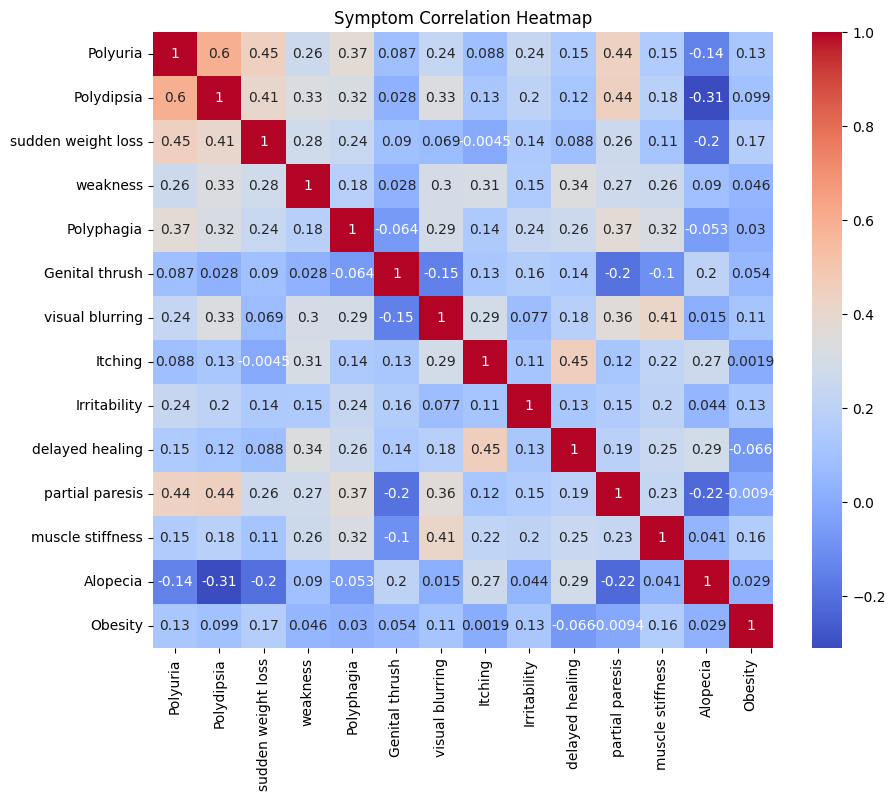

In [7]:
# on entire data set
corr = df[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap")
plt.show()

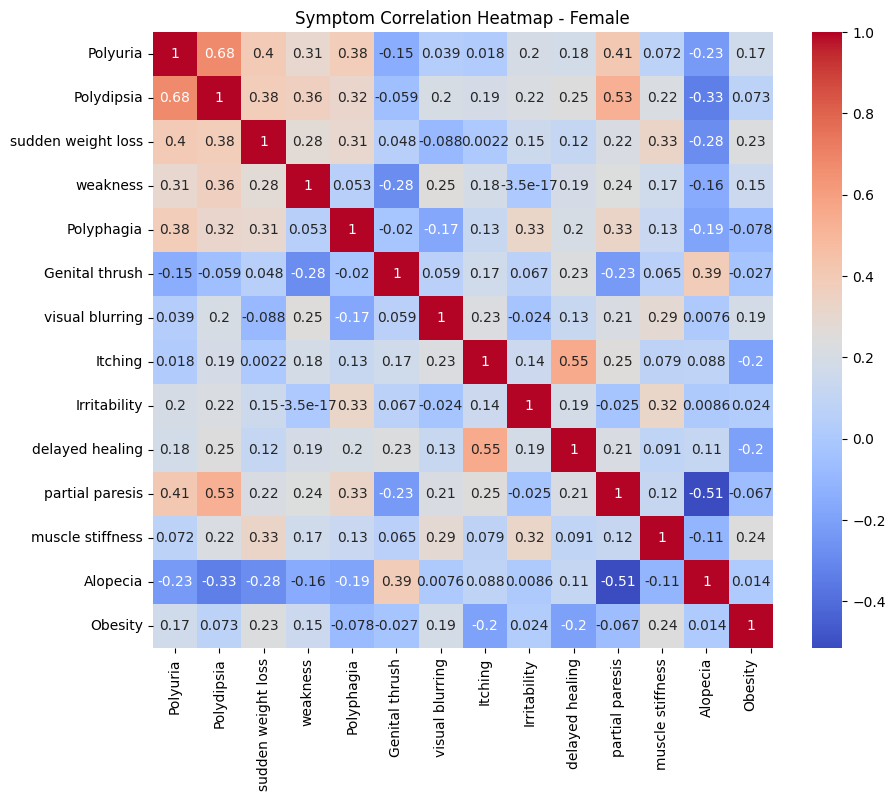

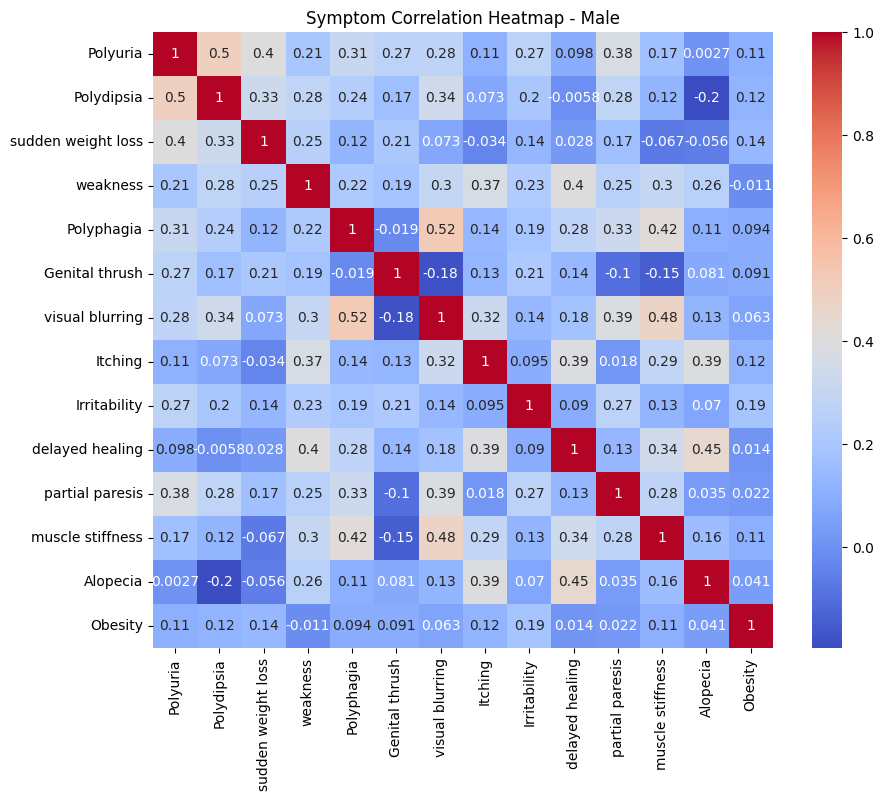

In [8]:
# gender_map = {"Male": 0, "Female": 1}
# Overall female and male
df_female = df.loc[df['Gender'] == 1]

corr = df_female[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Female")
plt.show()

# gender_map = {"Male": 0, "Female": 1}
df_male = df.loc[df['Gender'] == 0]

corr = df_male[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Male")
plt.show()

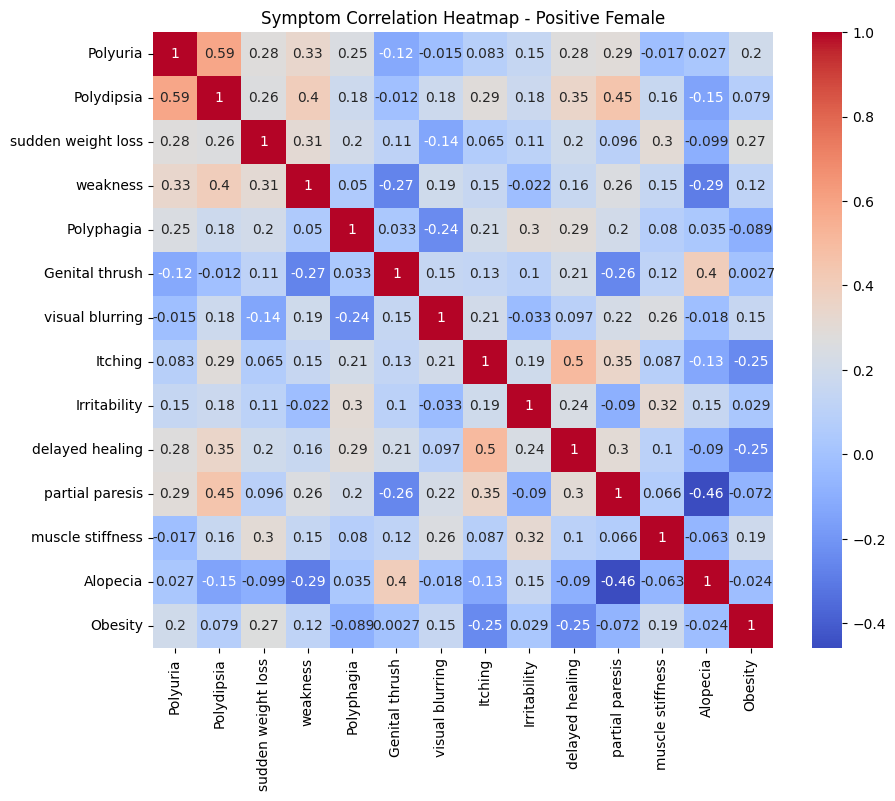

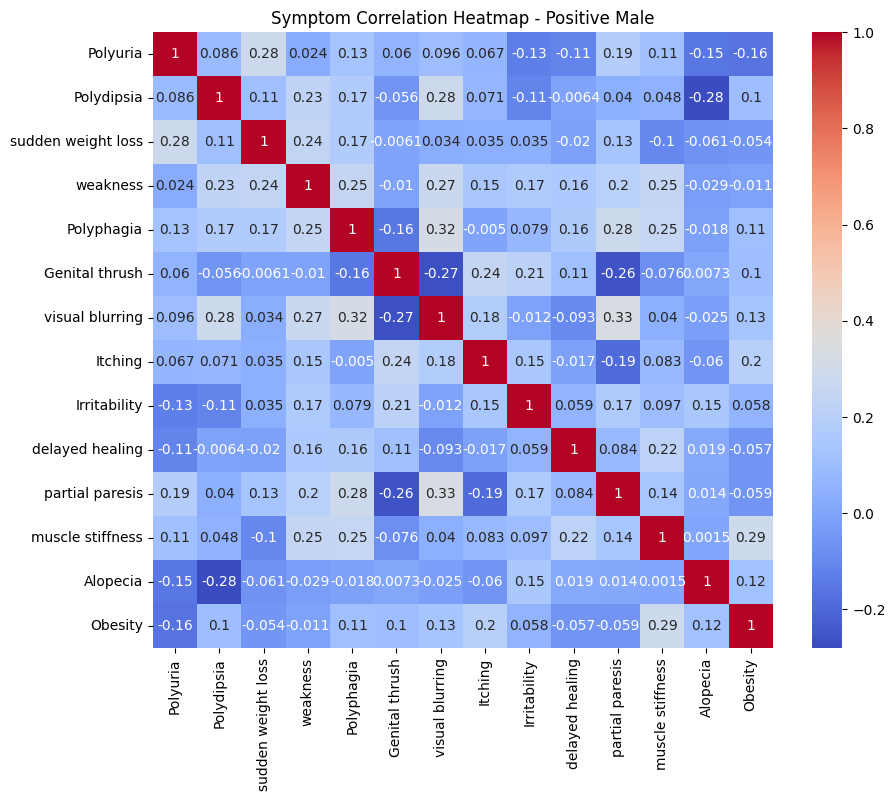

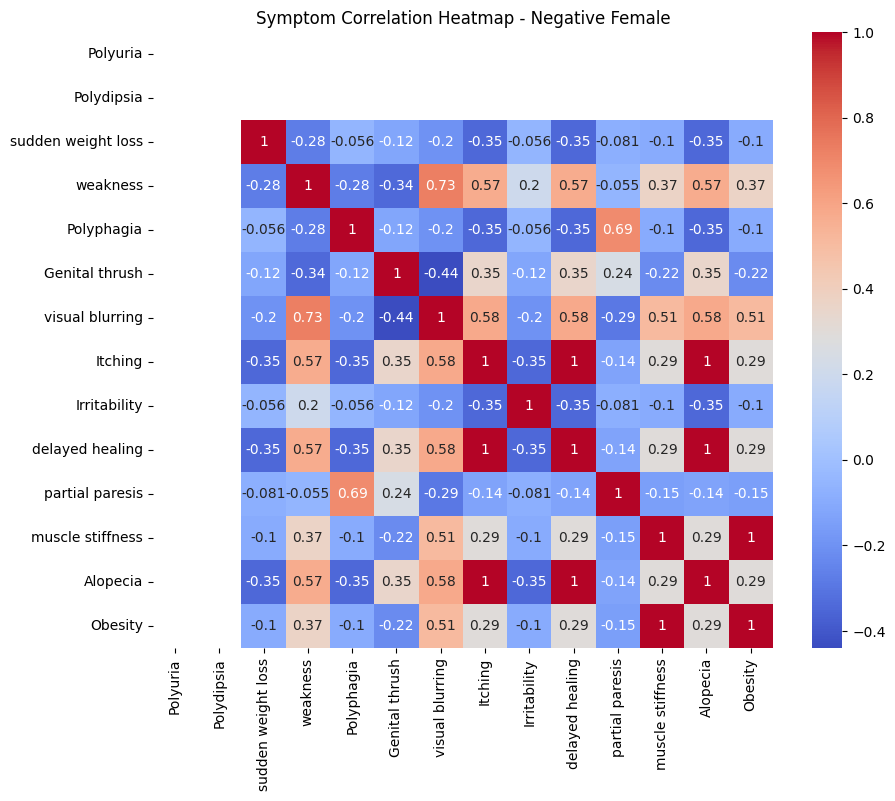

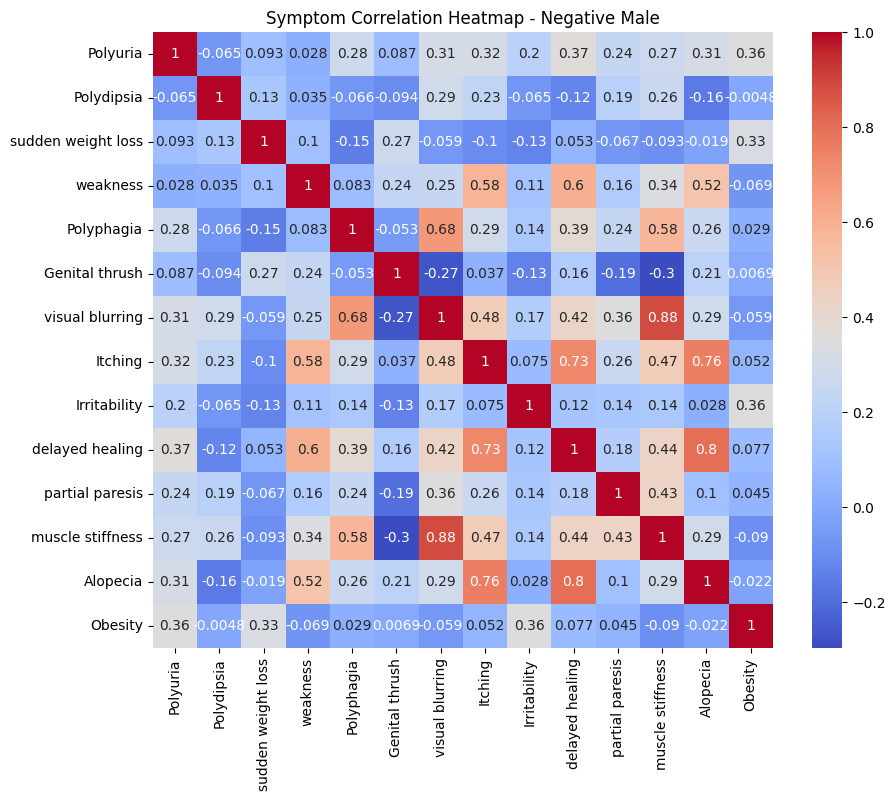

In [9]:
# Positive Female Cases
# class_map = {"Negative": 0, "Positive": 1}
df_female_positive = df_female.loc[df['class'] == 1]

corr = df_female_positive[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Positive Female")
plt.show()


# Positive Male Cases
df_male_positive = df_male.loc[df['class'] == 1]

corr = df_male_positive[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Positive Male")
plt.show()


# Negative Female Cases
df_female_negative = df_female.loc[df['class'] == 0]

corr = df_female_negative[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Negative Female")
plt.show()


# Negative Male Cases
df_male_negative = df_male.loc[df['class'] == 0]

corr = df_male_negative[symptom_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Symptom Correlation Heatmap - Negative Male")
plt.show()

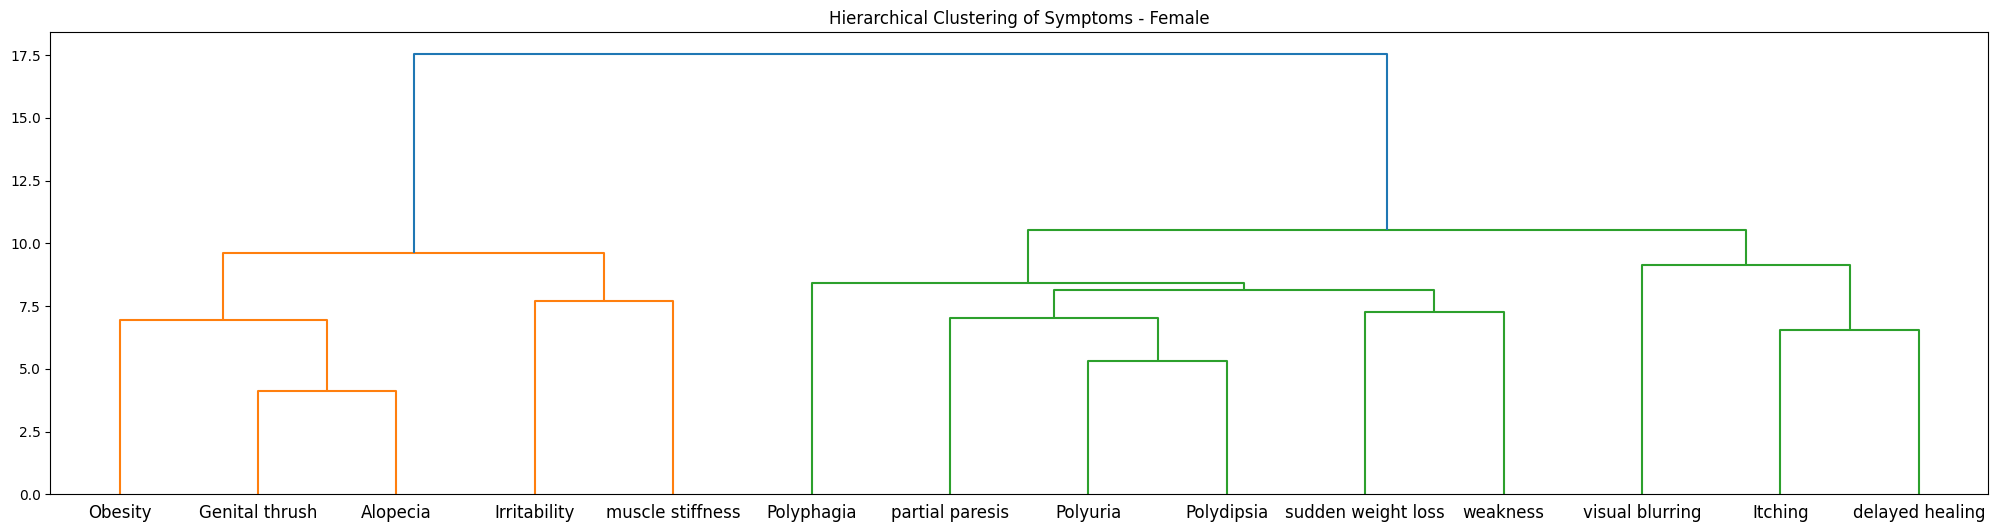

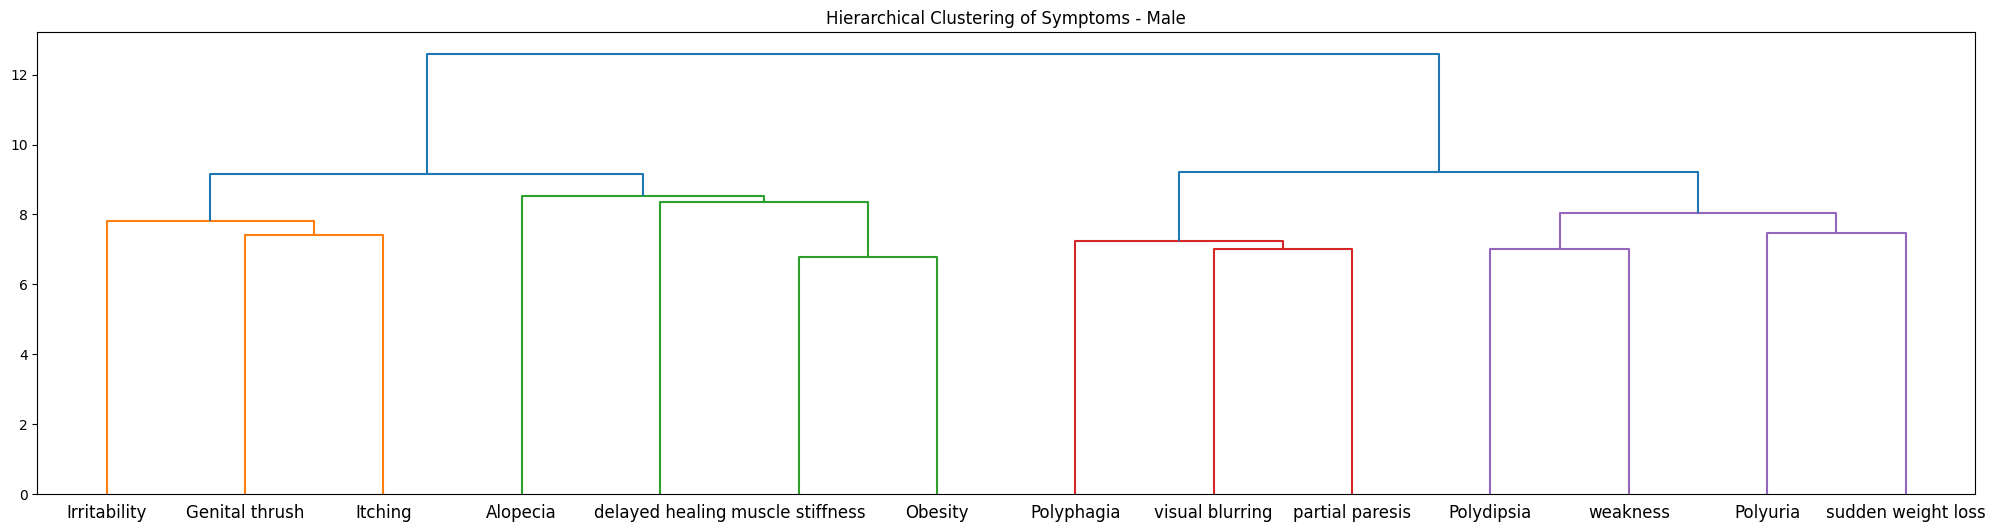

In [10]:
Z = linkage(df_female_positive[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Female")
plt.show()


Z = linkage(df_male_positive[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Male")
plt.show()

In [18]:
df.groupby(["AgeGroup", "class"])[symptom_cols].mean()

C:\Users\shafe\AppData\Local\Temp\ipykernel_22356\3624465728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["AgeGroup", "class"])[symptom_cols].mean()


Polyuria  Polydipsia  sudden weight loss  weakness  \
AgeGroup class                                                       
<30      0      0.000000    0.000000            0.133333  0.100000   
         1      0.600000    0.333333            0.466667  0.400000   
30–44    0      0.054795    0.041096            0.246575  0.356164   
         1      0.716814    0.672566            0.495575  0.637168   
45–59    0      0.000000    0.068493            0.095890  0.602740   
         1      0.786765    0.779412            0.742647  0.727941   
60+      0      0.458333    0.000000            0.000000  0.583333   
         1      0.821429    0.678571            0.428571  0.732143   

                Polyphagia  Genital thrush  visual blurring   Itching  \
AgeGroup class                                                          
<30      0        0.033333        0.000000         0.000000  0.000000   
         1        0.466667        0.133333         0.466667  0.200000   
30–44    0        0.082192        0.342466         0.054795  0.287671   
         1        0.522124        0.256637         0.442478  0.504425   
45–59    0        0.315068        0.095890         0.452055  0.753425   
         1        0.602941        0.227941         0.566176  0.463235   
60+      0        0.750000        0.041667         0.875000  0.958333   
         1        0.732143        0.375000         0.732143  0.553571   

                Irritability  delayed healing  partial paresis  \
AgeGroup class                                                   
<30      0          0.000000         0.000000         0.033333   
         1          0.066667         0.466667         0.533333   
30–44    0          0.054795         0.205479         0.068493   
         1          0.309735         0.451327         0.522124   
45–59    0          0.054795         0.657534         0.232877   
         1          0.301471         0.507353         0.654412   
60+      0          0.333333         0.958333         0.375000   
         1          0.589286         0.464286         0.642857   

                muscle stiffness  Alopecia   Obesity  
AgeGroup class                                        
<30      0              0.000000  0.000000  0.000000  
         1              0.466667  0.133333  0.000000  
30–44    0              0.041096  0.342466  0.136986  
         1              0.415929  0.185841  0.185841  
45–59    0              0.506849  0.726027  0.178082  
         1              0.389706  0.205882  0.198529  
60+      0              0.833333  0.958333  0.166667  
         1              0.500000  0.482143  0.232143

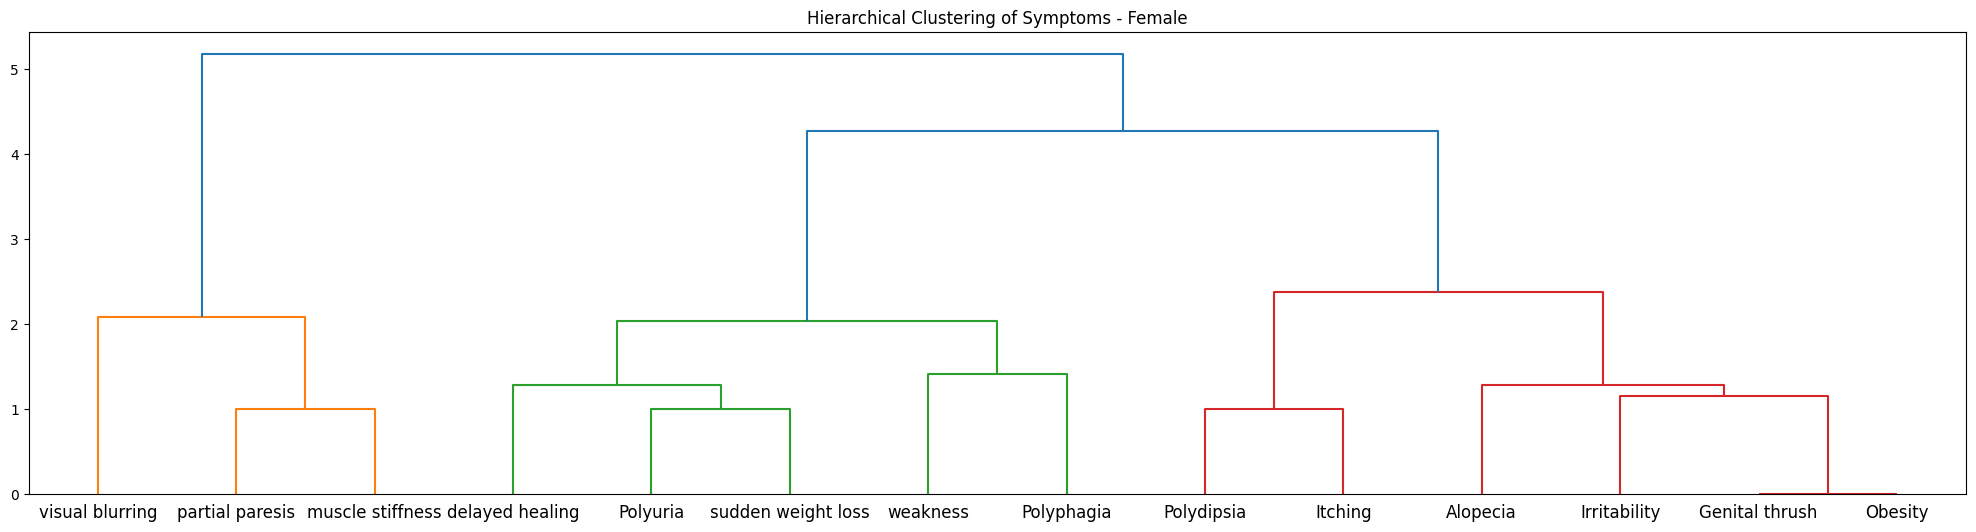

In [19]:
df_female_positive_less_thirty = df_female_positive.loc[df['AgeGroup'] == '<30']
Z = linkage(df_female_positive_less_thirty[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Female")
plt.show()

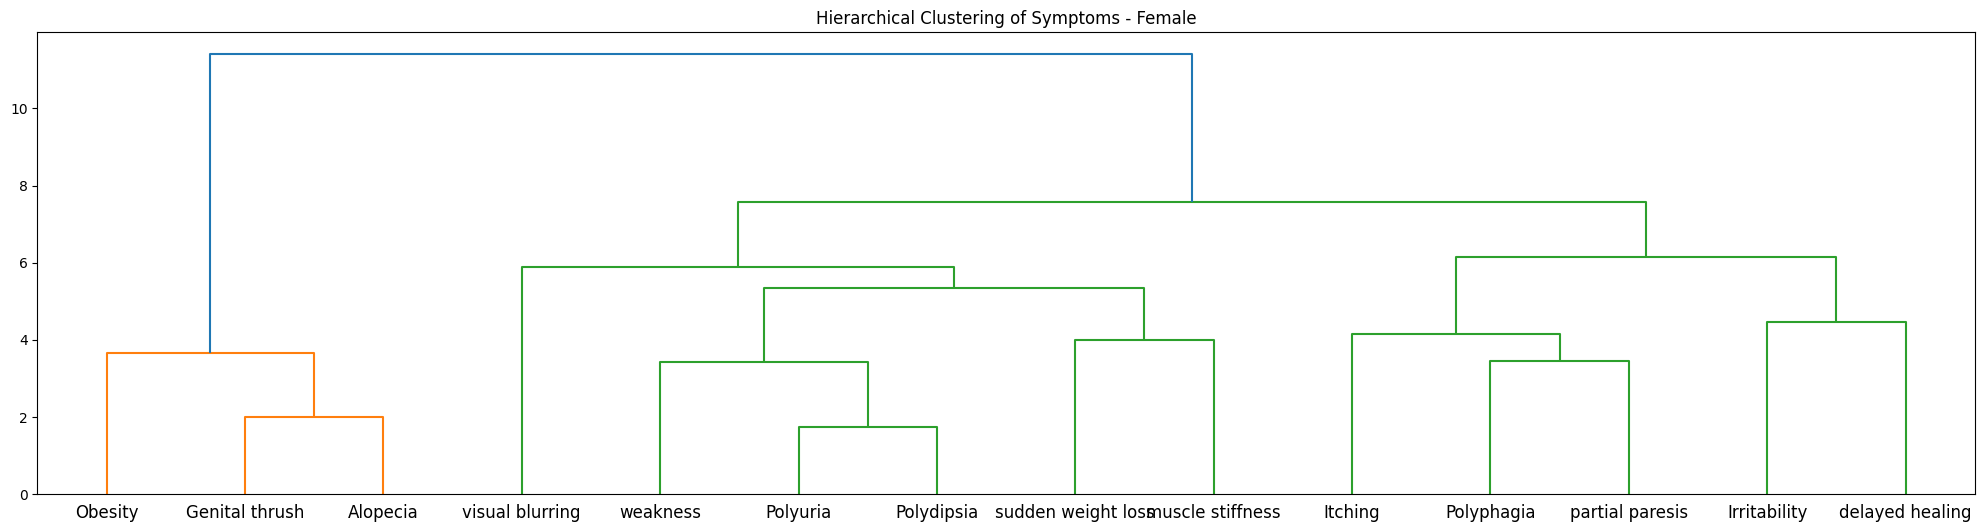

In [22]:
df_female_positive_30_44 = df_female_positive.loc[df['AgeGroup'] == '30–44']
df_female_positive_30_44
Z = linkage(df_female_positive_30_44[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Female")
plt.show()


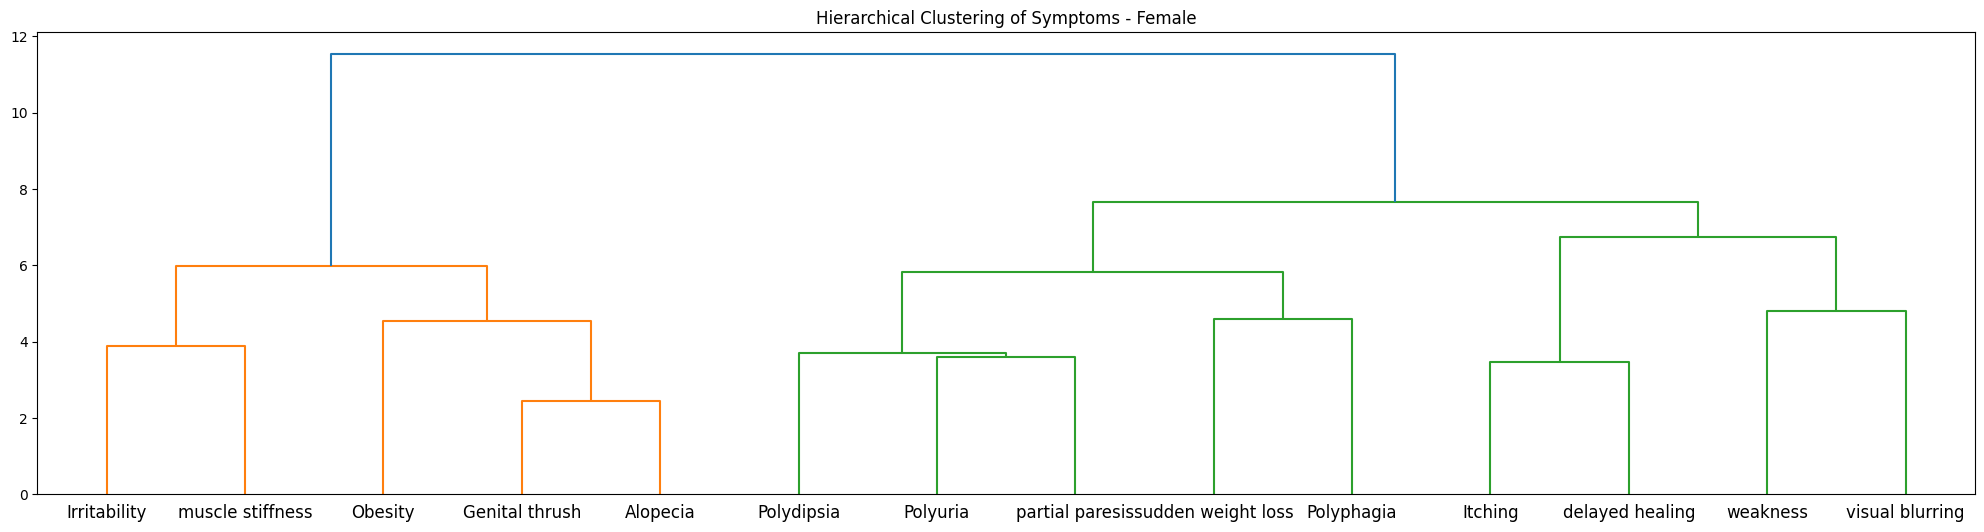

In [23]:
df_female_positive_45_59 = df_female_positive.loc[df['AgeGroup'] == '45–59']
Z = linkage(df_female_positive_45_59[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Female")
plt.show()


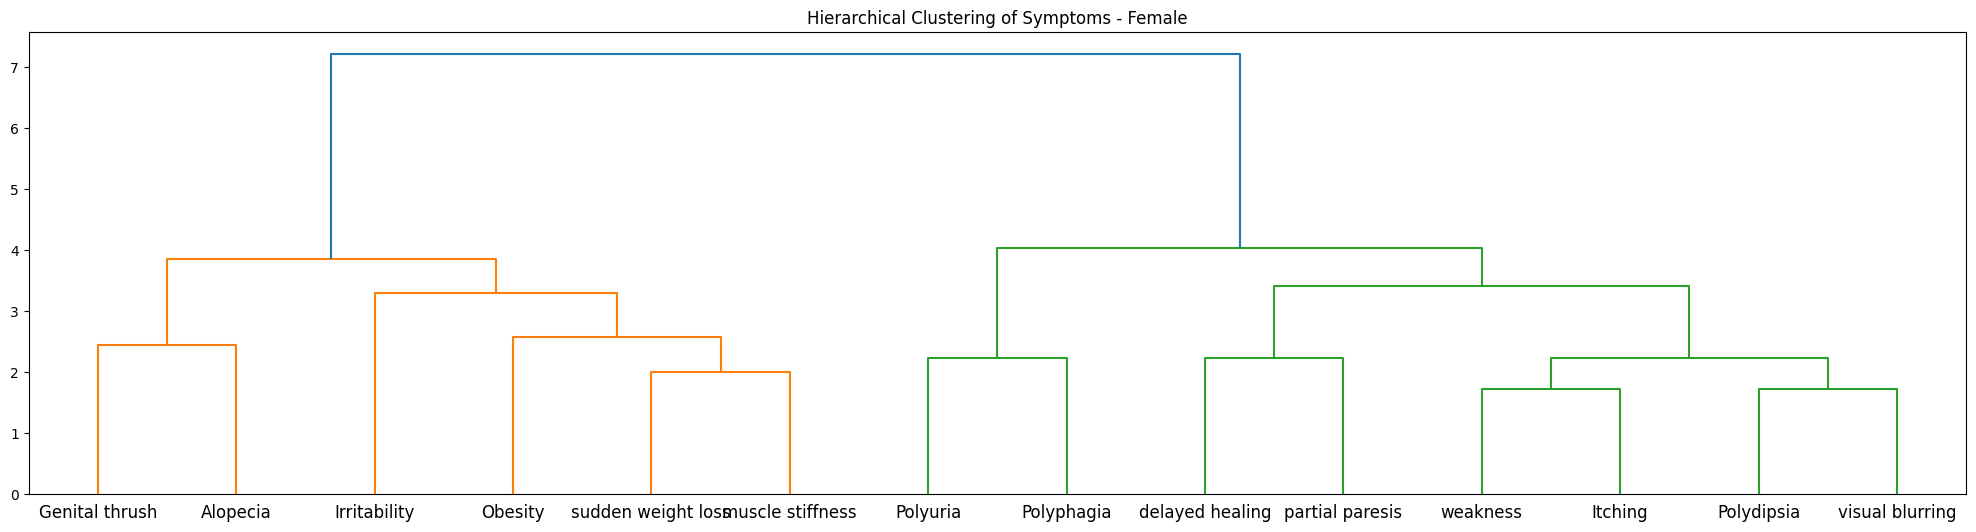

In [24]:
df_female_positive_45_59 = df_female_positive.loc[df['AgeGroup'] == '60+']
Z = linkage(df_female_positive_45_59[symptom_cols].T, method='ward')

plt.figure(figsize=(25,6))
dendrogram(Z, labels=symptom_cols)
plt.title("Hierarchical Clustering of Symptoms - Female")
plt.show()


In [11]:
X = df[['Age','Gender'] + list(symptom_cols)]
y = df['class']

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.165053
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                  class   No. Observations:                  520
Model:                          Logit   Df Residuals:                      503
Method:                           MLE   Df Model:                           16
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.7523
Time:                        13:06:20   Log-Likelihood:                -85.827
converged:                       True   LL-Null:                       -346.46
Covariance Type:            nonrobust   LLR p-value:                1.067e-100
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.6046      0.995     -1.613      0.107      -3.555       0.346
Age 

In [12]:
np.exp(model.params)

const                   0.200972
Age                     0.950119
Gender                 77.570157
Polyuria               84.735923
Polydipsia            159.244575
sudden weight loss      1.209644
weakness                2.263847
Polyphagia              3.299485
Genital thrush          6.447231
visual blurring         2.498960
Itching                 0.060632
Irritability           10.388796
delayed healing         0.675951
partial paresis         3.187711
muscle stiffness        0.482507
Alopecia                1.162256
Obesity                 0.748985
dtype: float64

In [13]:
kmeans = KMeans(n_clusters=7)
df_female_positive['cluster'] = kmeans.fit_predict(df_female_positive[symptom_cols])

C:\Users\shafe\AppData\Local\Temp\ipykernel_22356\2531218704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_female_positive['cluster'] = kmeans.fit_predict(df_female_positive[symptom_cols])


In [14]:
df_female_positive.groupby('cluster')[symptom_cols].mean()

,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
cluster,,,,,,,,,,,,,,
0,0.900000,0.800000,0.433333,0.633333,0.700000,0.166667,0.633333,0.933333,0.033333,0.933333,0.900000,0.000000,0.066667,0.000000
1,0.760000,0.520000,1.000000,0.680000,1.000000,0.000000,0.000000,0.040000,0.160000,0.240000,0.520000,0.360000,0.000000,0.120000
2,0.800000,0.900000,0.100000,0.800000,0.100000,0.000000,0.900000,0.000000,0.100000,0.100000,0.000000,0.100000,0.300000,0.000000
3,0.840000,1.000000,0.840000,0.840000,0.960000,0.160000,0.640000,0.860000,0.680000,0.920000,0.860000,0.840000,0.060000,0.120000
4,0.285714,0.000000,0.142857,0.142857,0.285714,0.071429,0.000000,0.000000,0.285714,0.000000,0.000000,0.000000,0.285714,0.142857
5,1.000000,0.931034,1.000000,1.000000,0.310345,0.034483,1.000000,0.241379,0.103448,0.241379,0.896552,0.689655,0.000000,0.655172
6,0.000000,0.133333,0.133333,0.000000,0.400000,0.133333,1.000000,0.533333,0.000000,0.000000,0.866667,0.533333,0.133333,0.000000


In [ ]:
# Note: learning from ChatGPT